# 02 - Veri Ön İşleme
## Uydu Telemetri Anomali Tespiti

EDA aşamasında keşfedilen yapıya uygun olarak telemetri verilerini makine öğrenmesi modelleri için hazırlayacağız.

### Adımlar:
1. Veri Yükleme ve Ham Veri Doğrulama
2. Eksik Veri Politikası
3. Gürültü Temizleme
4. Outlier Tespiti ve Kırpma
5. Normalizasyon ve Ölçeklendirme
6. Zaman Serisi Segmentasyonu
7. Veri Dengeleme
8. Train/Validation/Test Split
9. İşlenmiş Veriyi Kaydetme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import warnings
import os
import sys

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

sys.path.insert(0, '..')
from src.preprocessor import TelemetriPreprocessor

print('Kütüphaneler ve Preprocessor yüklendi.')

Kütüphaneler ve Preprocessor yüklendi.


---
## Bölüm 1: Veri Yükleme ve Ham Veri Doğrulama

In [2]:
segments = pd.read_csv('../data/raw/segments.csv')
dataset = pd.read_csv('../data/raw/dataset.csv')

segments['timestamp'] = pd.to_datetime(segments['timestamp'])
segments = segments.sort_values(by=['channel', 'timestamp']).reset_index(drop=True)

print(f'Segments shape: {segments.shape}')
display(segments.head(3))

Segments shape: (303493, 8)


,channel,timestamp,value,label,sampling,anomaly,segment,train
0,CADC0872,2022-01-04 20:00:50+00:00,-0.000011,a3,5,0,1818,1
1,CADC0872,2022-01-04 20:00:55+00:00,-0.000011,a3,5,0,1818,1
2,CADC0872,2022-01-04 20:01:00+00:00,-0.000006,a3,5,0,1818,1


In [3]:
segments['time_diff'] = segments.groupby('channel')['timestamp'].diff().dt.total_seconds()

print('=== Örnekleme Aralığı İstatistikleri (Saniye) ===')
display(segments['time_diff'].describe())

median_freq = segments['time_diff'].median()
print(f'\nBeklenen Örnekleme Periyodu: ~{median_freq} saniye')

=== Örnekleme Aralığı İstatistikleri (Saniye) ===


count    3.034840e+05
mean     2.711723e+02
std      5.046048e+04
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.085579e+07
Name: time_diff, dtype: float64


Beklenen Örnekleme Periyodu: ~1.0 saniye


---
## Bölüm 2: Eksik Veri Politikası

OPS-SAT metodolojisi (Ruszczak et al. 2024) eksik veriyi doldurmaz. Ham telemetride boşluklar bilinçli olarak korunur, çünkü:

- Eksik nokta sayısı bir özellik olarak kodlanır: `gaps_squared` (*"the squared number of missing data points"*). `len` ve `duration` da segment uzunluğu/süresini taşır.
- Veri boşlukları bir anomali türüdür (kısa/uzun data gap, makale Şekil 4); doldurmak bu anomali imzasını siler.
- İnterpolasyon makalede yalnız dar bir adımda (yumuşatılmış segmentlerden `smooth10/20_n_peaks` hesaplamak için) kullanılır, global doldurma stratejisi değildir.

> Aşağıdaki hücre klasik doldurma yöntemlerini yapay boşluk açılmış bir sinyalde yalnızca karşılaştırma/gösterim amaçlı çizer; kanonik pipeline'da kullanılmaz (Bölüm 6'da `impute_method='none'`).

In [4]:
# GOSTERIM: klasik doldurma yontemlerini yapay bosluk acilmis bir sinyalde karsilastiriyoruz.
# OPS-SAT metodolojisi bu yontemleri KULLANMAZ (bosluklar gaps_squared/len/duration ile korunur).
sample_df = segments[segments['channel'] == 'CADC0872'].copy().head(500)
np.random.seed(42)
mask = np.random.rand(len(sample_df)) < 0.05
sample_df.loc[mask, 'value'] = np.nan

ffill_res = sample_df['value'].ffill()

linear_res = sample_df['value'].interpolate(method='linear')

spline_res = sample_df['value'].interpolate(method='spline', order=3)

from sklearn.impute import KNNImputer
knn = KNNImputer(n_neighbors=5)
knn_res = knn.fit_transform(sample_df[['value']])[:, 0]

fig = go.Figure()
fig.add_trace(go.Scatter(y=sample_df['value'], mode='markers', name='Orijinal Veri (NaN kısımları boş)', marker=dict(color='black', size=6)))
fig.add_trace(go.Scatter(y=ffill_res, mode='lines', name='Forward Fill', line=dict(dash='dash', width=1)))
fig.add_trace(go.Scatter(y=linear_res, mode='lines', name='Linear', line=dict(dash='dot', width=1)))
fig.add_trace(go.Scatter(y=knn_res, mode='lines', name='KNN (k=5)', line=dict(dash='dashdot', width=1)))

fig.update_layout(title='Eksik Veri Doldurma Stratejileri Karşılaştırması', template='plotly_dark', height=500)
fig.show()

---
## Bölüm 3: Gürültü Temizleme

Manyetometre veya fotodiyot verilerindeki yüksek frekanslı sinyal gürültülerini yumuşatmak modelin genel trendi öğrenmesini kolaylaştırır.

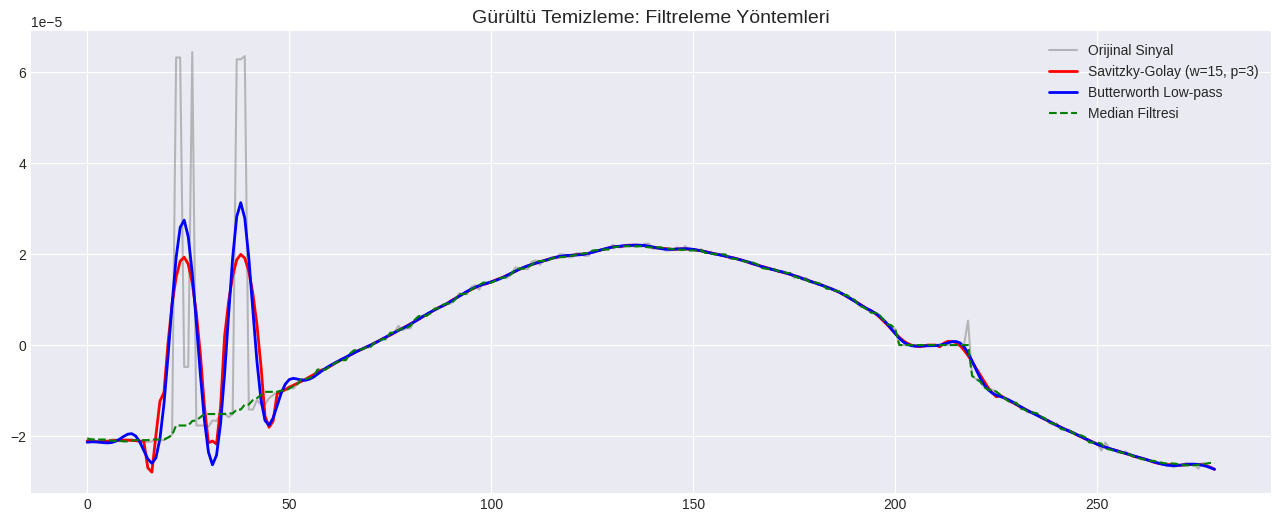

In [5]:
from scipy import signal

noisy_signal = segments[(segments['channel'] == 'CADC0872') & (segments['segment'] == 1)]['value'].values

savgol_res = signal.savgol_filter(noisy_signal, window_length=15, polyorder=3)

b, a = signal.butter(4, 0.2, 'lowpass')
butter_res = signal.filtfilt(b, a, noisy_signal)

median_res = signal.medfilt(noisy_signal, kernel_size=15)

plt.figure(figsize=(16, 6))
plt.plot(noisy_signal, label='Orijinal Sinyal', alpha=0.5, color='gray')
plt.plot(savgol_res, label='Savitzky-Golay (w=15, p=3)', color='red', linewidth=2)
plt.plot(butter_res, label='Butterworth Low-pass', color='blue', linewidth=2)
plt.plot(median_res, label='Median Filtresi', color='green', linestyle='dashed')
plt.legend()
plt.title('Gürültü Temizleme: Filtreleme Yöntemleri', fontsize=14)
plt.show()


Savitzky-Golay filtresi, sinyalin şeklini ve peak (tepe) noktalarını en iyi koruyan filtre olduğu için kullanılacaktır.

---
## Bölüm 4: Outlier Tespiti ve İşleme

In [6]:
def check_outliers(df, col, method='iqr', threshold=3.5):
    if method == 'iqr':
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        return ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).mean() * 100
    elif method == 'zscore':
        z = np.abs((df[col] - df[col].mean()) / df[col].std())
        return (z > threshold).mean() * 100
    elif method == 'mod_zscore':
        median = df[col].median()
        mad = np.median(np.abs(df[col] - median))
        z = 0.6745 * np.abs(df[col] - median) / (mad if mad > 0 else 1e-6)
        return (z > threshold).mean() * 100

outlier_df = []
for ch in segments['channel'].unique():
    ch_data = segments[segments['channel'] == ch]
    outlier_df.append({
        'Kanal': ch,
        'IQR (%)': check_outliers(ch_data, 'value', 'iqr'),
        'Z-Score (%)': check_outliers(ch_data, 'value', 'zscore'),
        'Mod-Z-Score (%)': check_outliers(ch_data, 'value', 'mod_zscore')
    })
    
out_df = pd.DataFrame(outlier_df).set_index('Kanal')
display(out_df.round(2).style.background_gradient(cmap='Reds'))

,IQR (%),Z-Score (%),Mod-Z-Score (%)
Kanal,,,
CADC0872,0.000000,0.000000,0.000000
CADC0873,0.000000,0.000000,0.000000
CADC0874,0.010000,0.000000,0.000000
CADC0884,0.000000,0.000000,0.000000
CADC0886,0.000000,0.000000,4.290000
CADC0888,0.100000,0.000000,26.850000
CADC0890,7.470000,0.000000,18.940000
CADC0892,0.630000,0.020000,27.090000
CADC0894,15.740000,0.990000,34.970000


Anomali tespitinde outlierlar aslında anomalinin kendisi olabileceği için tamamen silmek yerine, ekstrem durumları kırpmak (clipping) tercih edilir. Mod-Z-Score kullanılacaktır.

---
## Bölüm 5: Normalizasyon ve Ölçeklendirme

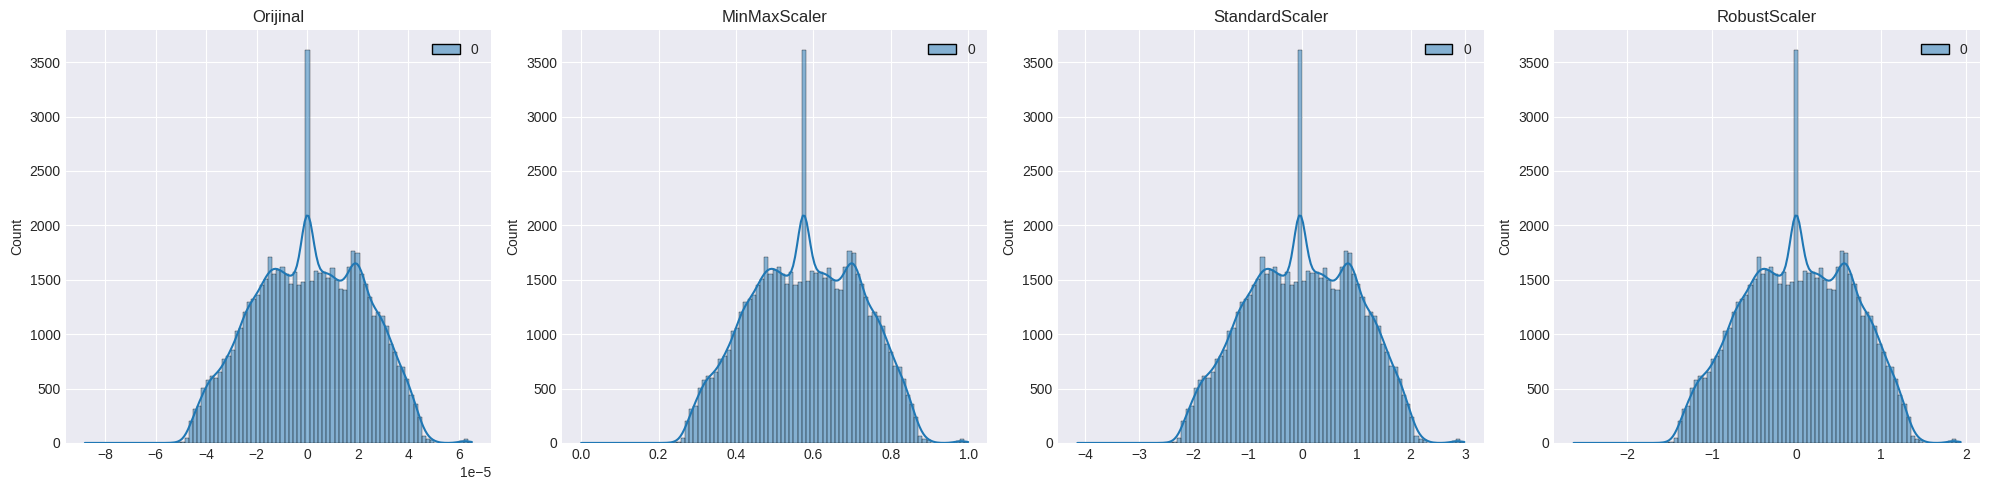

In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

sample_data = segments[segments['channel'] == 'CADC0872'][['value']].values

mm_scaler = MinMaxScaler()
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

mm_res = mm_scaler.fit_transform(sample_data)
std_res = std_scaler.fit_transform(sample_data)
rob_res = rob_scaler.fit_transform(sample_data)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.histplot(sample_data, ax=axes[0], color='gray', kde=True).set_title('Orijinal')
sns.histplot(mm_res, ax=axes[1], color='blue', kde=True).set_title('MinMaxScaler')
sns.histplot(std_res, ax=axes[2], color='red', kde=True).set_title('StandardScaler')
sns.histplot(rob_res, ax=axes[3], color='green', kde=True).set_title('RobustScaler')

plt.tight_layout()
plt.show()

Aykırı değerlerin ölçeği bozmasını engellemek için RobustScaler tercih edilmiştir.

---
## Bölüm 6: Resmi Split ve Preprocessor

Değerlendirme, `dataset.csv`'deki `train` kolonuyla tanımlı resmi split üzerinde yapılır, T (1594 segment) eğitim, Ψ (529 segment) test. Ölçekleyici ve tüm dönüşümler yalnızca T üzerinde fit edilir, Ψ'ye sadece uygulanır. Böylece test seti bilgisi eğitime sızmaz. Kanonik özellik seti: 18 resmi ESA handcrafted feature.

In [8]:
ESA_18_FEATURES = [
    'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks',
    'duration', 'len', 'gaps_squared', 'len_weighted',
    'var_div_duration', 'var_div_len',
    'smooth10_n_peaks', 'smooth20_n_peaks',
    'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var',
]

train_df = dataset[dataset['train'] == 1].copy()
test_df  = dataset[dataset['train'] == 0].copy()
print(f"Resmi split - T (eğitim): {len(train_df)} ({train_df['anomaly'].sum()} anomali)")
print(f"Resmi split - Ψ (test) : {len(test_df)} ({test_df['anomaly'].sum()} anomali)")

X_train_raw = train_df[ESA_18_FEATURES]
X_test_raw  = test_df[ESA_18_FEATURES]
y_train = train_df['anomaly'].reset_index(drop=True)
y_test  = test_df['anomaly'].reset_index(drop=True)

preprocessor = TelemetriPreprocessor(
    impute_method='none',  # OPS-SAT: bosluklar doldurulmaz (gaps_squared ile korunur)
    filter_method=None,
    outlier_method='mod_zscore',
    scaling_method='robust',
    outlier_threshold=4.0,
)
preprocessor.fit(X_train_raw)
X_train_p = preprocessor.transform(X_train_raw).reset_index(drop=True)
X_test_p  = preprocessor.transform(X_test_raw).reset_index(drop=True)

preprocessor.save_scaler('../models/robust_scaler.joblib')
preprocessor.generate_report('../data/processed/preprocessing_metadata.json')

print(f"\nX_train_p: {X_train_p.shape}, X_test_p: {X_test_p.shape}")
display(X_train_p.head(3))

Resmi split - T (eğitim): 1594 (321 anomali)
Resmi split - Ψ (test) : 529 (113 anomali)
Scaler ../models/robust_scaler.joblib konumuna kaydedildi.
Ön işleme raporu kaydedildi: ../data/processed/preprocessing_metadata.json

X_train_p: (1594, 18), X_test_p: (529, 18)


,mean,var,std,kurtosis,skew,n_peaks,duration,len,gaps_squared,len_weighted,var_div_duration,var_div_len,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var
0,-0.000018,-7.435731e-09,-0.000032,2.358929,0.831089,0.000006,0.348950,1.330189,-0.309382,0.337838,-1.497377e-08,-3.101582e-08,0.000006,0.000006,-0.052632,-0.285714,2.924839e-07,4.143891e-07
1,-0.000039,8.364062e-10,0.000003,0.124353,0.637276,0.000000,1.621971,1.883529,0.088480,1.668919,-1.435609e-08,-3.078631e-08,0.000000,0.000000,0.000000,-0.214286,-1.229328e-07,-5.368252e-08
2,0.000035,-1.614576e-09,-0.000006,2.241550,-1.281872,0.000006,2.384491,1.883529,0.240499,2.466216,-1.674886e-08,-3.165959e-08,0.000006,0.000006,-0.157895,-0.392857,-1.142597e-07,-2.441294e-09


---
## Bölüm 7: Sınıf Dengesizliği ve Veri Dengeleme

SMOTE yalnızca eğitim katmanına uygulanır. Sentetik azınlık örnekleri test noktalarından türetilmemelidir, bu yüzden Ψ test setine asla dokunulmaz.

In [9]:
from imblearn.over_sampling import SMOTE

print("SMOTE Öncesi Sınıf Dağılımı")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_p, y_train)
y_train_sm = pd.Series(y_train_sm, name='anomaly')

print("\nSMOTE Sonrası Sınıf Dağılımı")
print(y_train_sm.value_counts())
print(f"\n{y_test.value_counts().to_dict()}")

SMOTE Öncesi Sınıf Dağılımı
anomaly
0    1273
1     321
Name: count, dtype: int64

SMOTE Sonrası Sınıf Dağılımı
anomaly
1    1273
0    1273
Name: count, dtype: int64

{0: 416, 1: 113}


---
## Bölüm 8: Validation Ayırma

Model seçimi ve erken durdurma için T içinden bir validation kümesi ayırıyoruz.

In [10]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm, y_train_sm,
    test_size=0.15, random_state=42, stratify=y_train_sm,
)

print('Veri Seti Bölme İstatistikleri')
print(f"Train             : {X_tr.shape[0]} satır  ({y_tr.mean():.1%} anomali)")
print(f"Validation        : {X_val.shape[0]} satır  ({y_val.mean():.1%} anomali)")
print(f"Test              : {X_test_p.shape[0]} satır  ({y_test.mean():.1%} anomali, dokunulmadı)")

Veri Seti Bölme İstatistikleri
Train             : 2164 satır  (50.0% anomali)
Validation        : 382 satır  (50.0% anomali)
Test              : 529 satır  (21.4% anomali, dokunulmadı)


---
## Bölüm 9: İşlenmiş Veriyi Kaydetme

In [11]:
import os
from sklearn.model_selection import train_test_split
os.makedirs('../data/processed', exist_ok=True)

# Gözetimli (NB04) — SMOTE'lu, ölçeklenmiş T split'i + ölçeklenmiş Ψ test
X_tr.to_parquet('../data/processed/X_train.parquet')
y_tr.to_frame('anomaly').to_parquet('../data/processed/y_train.parquet')
X_val.to_parquet('../data/processed/X_val.parquet')
y_val.to_frame('anomaly').to_parquet('../data/processed/y_val.parquet')
X_test_p.to_parquet('../data/processed/X_test.parquet')
y_test.to_frame('anomaly').to_parquet('../data/processed/y_test.parquet')

# Gözetimsiz (NB05) — aynı RobustScaler ile ölçeklenmiş ama SMOTE'SUZ T split'i
# (gözetimsiz protokol sentetik azınlık örneği istemez; yalnız-normal eğitim için).
X_tr_ns, X_val_ns, y_tr_ns, y_val_ns = train_test_split(
    X_train_p, y_train, test_size=0.15, random_state=42, stratify=y_train)
X_tr_ns.to_parquet('../data/processed/X_train_nosmote.parquet')
y_tr_ns.to_frame('anomaly').to_parquet('../data/processed/y_train_nosmote.parquet')
X_val_ns.to_parquet('../data/processed/X_val_nosmote.parquet')
y_val_ns.to_frame('anomaly').to_parquet('../data/processed/y_val_nosmote.parquet')

print("işlenmiş veri kaydedildi: data/processed/ (SMOTE'lu split [NB04] + SMOTE'suz split [NB05])")

işlenmiş veri kaydedildi: data/processed/ (SMOTE'lu split [NB04] + SMOTE'suz split [NB05])
